In [217]:
import pandas as pd

#-- load 
df_SL_rpk = pd.read_csv('../preprocessing/earliest_tp_rpk_avg_value_for_cohort_techreps_071626.csv').set_index('peptide')
df_hbdb_rpk = pd.read_csv('../preprocessing/hbdb_pass_100k_techreps_averaged_071626.csv').set_index('peptide')

df_sl_z = pd.read_csv('../z_score_df_SL_over_US_090226.csv').set_index('peptide')
df_hbdb_z = pd.read_csv('../z_hbdb_loo_results_090226.csv').set_index('peptide')

peps_metadata = (
pd.read_csv('../lassa_library_sequences_species_standardized_070726.csv').rename(columns={'seq_id': 'peptide'})
)
#-- correct wrong genus name
peps_metadata.loc[peps_metadata['genus'] == 'Arenavirus', 'genus'] = 'Mammarenavirus'

In [218]:
Z_THRESH = 3
SENS_MIN = 0.02
SPEC_MIN = 0.99

### calculate peptide sensitivity / specificity and select hits

In [219]:
#-- per peptide stats (sensitivity / specificity etc.)
def seropositivity_stats(df_sl_z, df_hbdb_z, metadata, z_thresh=Z_THRESH):
    pass_sl = df_sl_z > z_thresh
    pass_hbdb = df_hbdb_z > z_thresh

    stats = pd.concat(
        [pass_sl.mean(axis=1), pass_hbdb.mean(axis=1)], 
        axis=1, keys=['frac_pass_z_in_SL', 'frac_pass_z_in_US'] #performs multiindex on colums
    ).reset_index()

    stats = stats.merge(
        metadata[['peptide', 'sequence', 'species', 'genus', 'subfamily', 'family', 'order', 
                  'protein_name', 'accession', 'collection_date', 'collection_date_standardized', 'geo_loc_name', 'host']], 
                  on = 'peptide', how='left'
    )

    stats['delta'] = stats['frac_pass_z_in_SL'] - stats['frac_pass_z_in_US']
    stats['sensitivity'] = stats['frac_pass_z_in_SL']
    stats['specificity'] = 1 - stats['frac_pass_z_in_US']
    stats['youden'] = stats['sensitivity'] + stats['specificity'] - 1

    pass_bool = pd.concat([pass_sl, pass_hbdb], axis=1).reset_index()

    return stats, pass_bool

#-- get dataframes
df_fractions, df_pass_z_boolean = seropositivity_stats(df_sl_z, df_hbdb_z, peps_metadata)

hits = df_fractions[
    (df_fractions['sensitivity'] >= SENS_MIN) & 
    (df_fractions['specificity'] >= SPEC_MIN)
].copy()


### remove non-viral and plant viral families

In [220]:
#filtering out taxa I don't want to include downstream, such as Trypanosomatidae and Konkoviridae

TAXON_LEVEL = 'family'
TAXON_TO_REMOVE = ['Trypanosomatidae', 'Konkoviridae']

ACCESSION_TO_REMOVE = ['WAK75154.1', 'ANT96597.1'] #this is an ampicillin resistance protein from an artificial Zika 'vaccine' vector

hits = hits[~hits[TAXON_LEVEL].isin(TAXON_TO_REMOVE)].copy()

hits = hits[~hits['accession'].isin(ACCESSION_TO_REMOVE)]

In [221]:
hits['species'].nunique()
hits.shape

(3949, 19)

### add k-mer based clustering

In [222]:
import networkx as nx
from collections import defaultdict

K = 8

def get_kmers(sequence, k=K):
    sequence = str(sequence).upper()
    return {
        sequence[i:i+k]
        for i in range(len(sequence) - k + 1)
    }

kmer_to_peptides = defaultdict(list)

for peptide, sequence in hits[['peptide', 'sequence']].itertuples(index=False):
    for kmer in get_kmers(sequence):
        kmer_to_peptides[kmer].append(peptide)

In [223]:
G = nx.Graph()

# Every peptide is represented, including singleton peptides
G.add_nodes_from(hits['peptide'])

# Connect peptides sharing at least one exact 7-mer
for peptides in kmer_to_peptides.values():
    if len(peptides) > 1:
        for i in range(len(peptides)):
            for j in range(i + 1, len(peptides)):
                G.add_edge(peptides[i], peptides[j])

In [224]:
components = list(nx.connected_components(G))

cluster_assignments = []

for cluster_id, peptides in enumerate(components):
    for peptide in peptides:
        cluster_assignments.append({
            'peptide': peptide,
            'cluster_id': cluster_id
        })

cluster_assignments = pd.DataFrame(cluster_assignments)

### attach cluster IDs to hits

In [225]:
hits_z = hits.merge(
    cluster_assignments,
    on='peptide',
    how='left'
)

### determine species- and genus- discriminating clusters

In [226]:
cluster_species = (
    hits_z
    .groupby('cluster_id')['species']
    .nunique()
)

cluster_genus = (
    hits_z
    .groupby('cluster_id')['genus']
    .nunique()
)

hits_z['n_species_in_cluster'] = (
    hits_z['cluster_id'].map(cluster_species)
)

hits_z['n_genera_in_cluster'] = (
    hits_z['cluster_id'].map(cluster_genus)
)

hits_species_specific = hits_z[
    hits_z['n_species_in_cluster'] == 1
].copy()

hits_genus_specific = hits_z[
    hits_z['n_genera_in_cluster'] == 1
].copy()

In [227]:
print("hits:", len(hits))
print("species-specific:", len(hits_species_specific))
print("genus-specific:", len(hits_genus_specific))

hits: 3949
species-specific: 2069
genus-specific: 3354


### add df_z - build df_z_wide

In [228]:
df_z = pd.concat(
    [df_sl_z, df_hbdb_z],
    axis=1
)

df_z_wide = (
    hits_species_specific[
        [
            'peptide',
            'species',
            'genus',
            'family',
            'protein_name',
            'cluster_id'
        ]
    ]
    .drop_duplicates('peptide')
    .merge(
        df_z,
        left_on='peptide',
        right_index=True,
        how='left'
    )
)

In [229]:
print(df_z_wide.shape)
print(df_z_wide['cluster_id'].nunique())

(2069, 490)
1666


### calculate individual species breadth

In [230]:
def calculate_breadth(
    df,
    individual_cols,
    taxon_col,
    cohort
):

    records = []

    for taxon, taxon_df in df.groupby(taxon_col):

        for individual in individual_cols:

            positive = taxon_df[individual] > Z_THRESH

            breadth = taxon_df.loc[
                positive,
                'cluster_id'
            ].nunique()

            records.append({
                taxon_col: taxon,
                'individual': individual,
                'breadth': breadth,
                'cohort': cohort
            })

    return pd.DataFrame(records)

In [231]:
sl_cols = df_sl_z.columns.tolist()
hbdb_cols = df_hbdb_z.columns.tolist()

breadth_child = calculate_breadth(
    df_z_wide,
    sl_cols,
    'species',
    'SL'
)

breadth_hbdb = calculate_breadth(
    df_z_wide,
    hbdb_cols,
    'species',
    'HBDB'
)

breadth_species_df = pd.concat(
    [breadth_child, breadth_hbdb],
    ignore_index=True
)

### find the minimum breadth giving >= 98% HBDB specificity 

In [232]:
threshold_records = []

for species, group in breadth_species_df.groupby('species'):

    hbdb = group[group['cohort'] == 'HBDB']

    max_breadth = int(hbdb['breadth'].max())

    for k in range(1, max_breadth + 2):

        frac_hbdb_positive = (
            hbdb['breadth'] >= k
        ).mean()

        threshold_records.append({
            'species': species,
            'breadth_threshold': k,
            'frac_HBDB_positive': frac_hbdb_positive,
            'specificity': 1 - frac_hbdb_positive
        })

threshold_species_df = pd.DataFrame(threshold_records)

### pick lowest threshold with >= 98% specificity

for each species, what is the smallest number of independent reactive clusters required before calling someone positive, while keeping HBDB specificity at >= 98%?

In [233]:
species_thresholds = (
    threshold_species_df[
        threshold_species_df['specificity'] >= 0.98
    ]
    .sort_values(
        ['species', 'breadth_threshold']
    )
    .drop_duplicates(
        'species',
        keep='first'
    )
)

### attach threshold to each individual

In [234]:
breadth_species_df = breadth_species_df.merge(
    species_thresholds[
        ['species', 'breadth_threshold']
    ],
    on='species',
    how='left'
)

### define species-level seropositivity

In [235]:
breadth_species_df['seropositive'] = (
    breadth_species_df['breadth']
    >= breadth_species_df['breadth_threshold']
)

In [236]:
species_seropositivity = (
    breadth_species_df
    .groupby(['species', 'cohort'])
    .agg(
        n_positive=('seropositive', 'sum'),
        n_total=('seropositive', 'size'),
        fraction_positive=('seropositive', 'mean')
    )
    .reset_index()
)

### plot species specificity / seropositivity cohort distribution

In [237]:
species_plot.sort_values(
    'SL',
    ascending=False
)


cohort,species,HBDB,SL
137,Orthohantavirus sp.,0.0,0.989924
85,Mammarenavirus lassaense,0.0,0.979849
54,Henipavirus sp.,0.0,0.972292
153,Orthonairovirus haemorrhagiae,0.0,0.957179
130,Orthoflavivirus denguei,0.0,0.851385
106,Measles morbillivirus,0.0,0.755668
165,Orthonairovirus nairobiense,0.0,0.745592
118,Nairoviridae sp.,0.0,0.700252
149,Orthonairovirus erveense,0.0,0.682620
121,Ocetevirus paratemnopterygis,0.0,0.622166


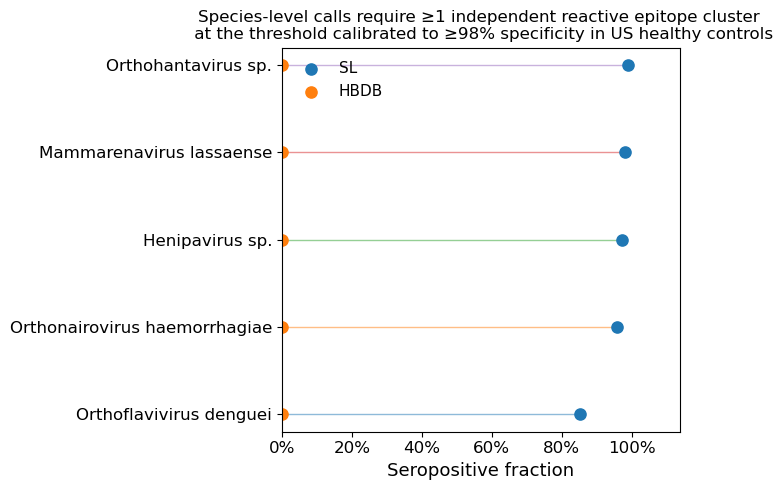

In [238]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Summarize seropositivity
species_plot = (
    breadth_species_df
    .groupby(['species', 'cohort'])['seropositive']
    .mean()
    .unstack()
    .fillna(0)
    .reset_index()
)

# Keep species with at least some SL seropositivity
species_plot = (
    species_plot
    .sort_values('SL', ascending=False)
)

# Optional: top 10 species
species_plot = species_plot.head(5).sort_values(
    'SL',
    ascending=True
)

fig, ax = plt.subplots(figsize=(7, 5))

y = np.arange(len(species_plot))

ax.scatter(
    species_plot['SL'],
    y,
    s=65,
    label='SL'
)

ax.scatter(
    species_plot['HBDB'],
    y,
    s=65,
    label='HBDB'
)

for i in range(len(species_plot)):
    ax.plot(
        [
            species_plot.iloc[i]['HBDB'],
            species_plot.iloc[i]['SL']
        ],
        [i, i],
        linewidth=1,
        alpha=0.5,
        zorder=0
    )

ax.set_yticks(y)
ax.set_yticklabels(
    species_plot['species'],
    fontsize=12
)

ax.set_xlabel(
    'Seropositive fraction',
    fontsize=13
)

ax.set_ylabel('')

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'{x:.0%}')
)

ax.tick_params(axis='x', labelsize=12)

ax.legend(
    frameon=False,
    fontsize=11
)

ax.set_xlim(0, max(species_plot['SL'].max(), 0.05) * 1.15)

plt.title('Species-level calls require ≥1 independent reactive epitope cluster \n at the threshold calibrated to ≥98% specificity in US healthy controls')
plt.tight_layout()
plt.show()

### next plot: distribution of independent epitope breadth

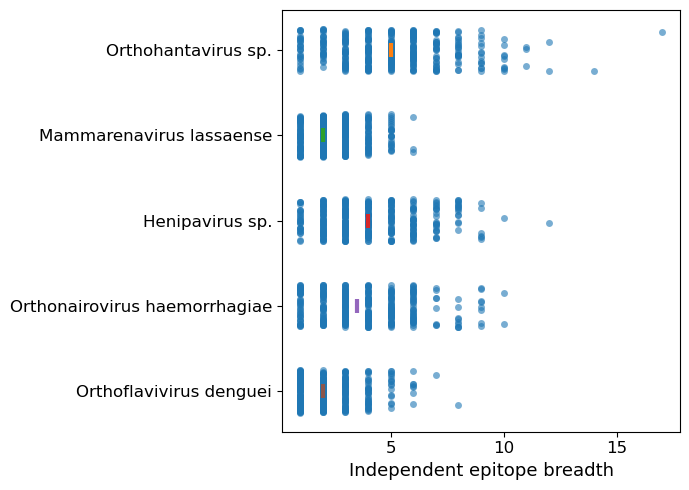

In [239]:
import seaborn as sns

species_order = species_plot['species'].tolist()[::-1]

plot_breadth = (
    breadth_species_df[
        (breadth_species_df['cohort'] == 'SL') &
        (breadth_species_df['seropositive'])
    ]
    .copy()
)

plot_breadth = plot_breadth[
    plot_breadth['species'].isin(species_order)
]


fig, ax = plt.subplots(figsize=(7, 5))

sns.stripplot(
    data=plot_breadth,
    x='breadth',
    y='species',
    order=species_order,   # SAME ORDER
    jitter=0.25,
    size=5,
    alpha=0.6,
    ax=ax
)

# Median breadth for each species
medians = (
    plot_breadth
    .groupby('species')['breadth']
    .median()
    .reindex(species_order)
)

# Show median as a larger marker
for i, median in enumerate(medians):
    ax.scatter(
        median,
        i,
        s=90,
        marker='|',
        linewidths=3,
        zorder=5
    )

ax.set_xlabel(
    'Independent epitope breadth',
    fontsize=13
)

ax.set_ylabel('')

ax.tick_params(
    axis='x',
    labelsize=12
)

ax.tick_params(
    axis='y',
    labelsize=12
)

plt.tight_layout()
plt.show()

### number of supporting peptide/clusters per species

In [240]:
species_support = (
    hits_species_specific
    .groupby('species')
    .agg(
        n_peptides=('peptide', 'nunique'),
        n_clusters=('cluster_id', 'nunique')
    )
    .reset_index()
)

species_support = (
    species_support
    .set_index('species')
    .reindex(species_order)
    .reset_index()
)

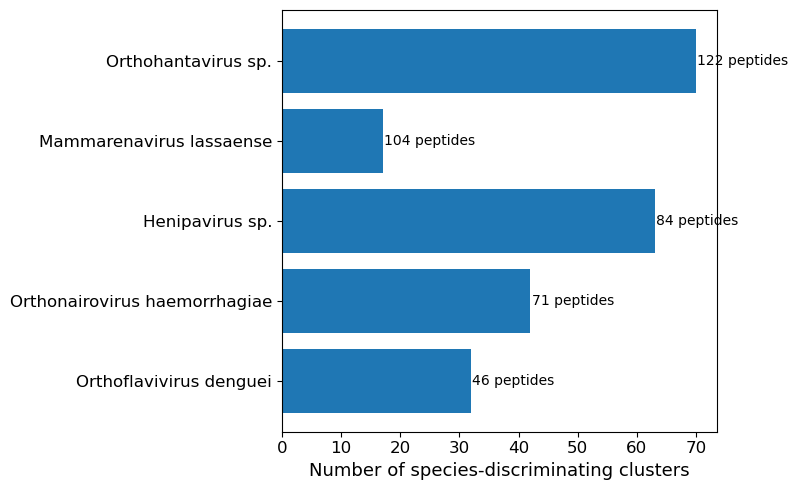

In [241]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    species_support['species'],
    species_support['n_clusters']
)

ax.set_xlabel(
    'Number of species-discriminating clusters',
    fontsize=13
)

ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

for i, row in species_support.iterrows():

    ax.text(
        row['n_clusters'] + 0.2,
        i,
        f"{row['n_peptides']} peptides",
        va='center',
        fontsize=10
    )
    
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### representative peptide RPK figure 

In [242]:
hits_species_specific

,peptide,frac_pass_z_in_SL,frac_pass_z_in_US,sequence,species,genus,subfamily,family,order,protein_name,...,collection_date_standardized,geo_loc_name,host,delta,sensitivity,specificity,youden,cluster_id,n_species_in_cluster,n_genera_in_cluster
0,AAA16239.1|polypeptide|Orthohantavirus_thailan...,0.032746,0.0,KIECPHSVNFGETSVTGQVELPALPITEAEQLVPESSCNMDNHQSL,Orthohantavirus sp.,Orthohantavirus,Mammantavirinae,Hantaviridae,Elliovirales,glycoproteins G1/G2 polypeptide,...,NaN,NaN,NaN,0.032746,0.032746,1.0,0.032746,0,1,1
1,AAA16239.1|polypeptide|Orthohantavirus_thailan...,0.040302,0.0,ATINTLTKVSWRKKADQVSASQNSFEVIEAETSFKGLCMLKHRMIE,Orthohantavirus sp.,Orthohantavirus,Mammantavirinae,Hantaviridae,Elliovirales,glycoproteins G1/G2 polypeptide,...,NaN,NaN,NaN,0.040302,0.040302,1.0,0.040302,0,1,1
5,AAA50545.1|hemagglutinin|Measles_morbillivirus...,0.025189,0.0,CHGEDSITIPYQGSGKGASFQLIKLGVWKSPTDMQSWVPLSTDDPV,Measles morbillivirus,Morbillivirus,Orthoparamyxovirinae,Paramyxoviridae,Mononegavirales,hemagglutinin,...,NaN,NaN,NaN,0.025189,0.025189,1.0,0.025189,3,1,1
6,AAA50545.1|hemagglutinin|Measles_morbillivirus...,0.027708,0.0,NLALGVINTLEWIPRFKVSPILFTVPIKEAGEHCRAPTYLPAEVYG,Measles morbillivirus,Morbillivirus,Orthoparamyxovirinae,Paramyxoviridae,Mononegavirales,hemagglutinin,...,NaN,NaN,NaN,0.027708,0.027708,1.0,0.027708,4,1,1
7,AAA63282.1|nucleoprotein|Measles_morbillivirus...,0.045340,0.0,FASRGTNMEDEADQYFSYDDSSSGDQSRSGWFENKEISDIEVQDPE,Measles morbillivirus,Morbillivirus,Orthoparamyxovirinae,Paramyxoviridae,Mononegavirales,nucleoprotein,...,NaN,NaN,NaN,0.045340,0.045340,1.0,0.045340,5,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3923,YP_011036812.1|polymerase|Frijoles_virus|isola...,0.075567,0.0,NWDITEKKFPHFKKKMFENFQADPDNEYISKIITDCLEKAQKEMFD,Phlebovirus limboense,Phlebovirus,NaN,Phenuiviridae,Hareavirales,RNA-dependent RNA polymerase,...,11/24/69,Panama: Canal Zone,Lutzomyia sp.,0.075567,0.075567,1.0,0.075567,1987,1,1
3927,YP_011036812.1|polymerase|Frijoles_virus|isola...,0.047859,0.0,RKSPLIELRSSDGSSKSNRLAILQRYAGDEPTVIKSLEEIGAGILG,Phlebovirus limboense,Phlebovirus,NaN,Phenuiviridae,Hareavirales,RNA-dependent RNA polymerase,...,11/24/69,Panama: Canal Zone,Lutzomyia sp.,0.047859,0.047859,1.0,0.047859,1988,1,1
3931,YP_089665.1|precursor|Sabia_virus|?|?|?|?|?|SP...,0.030227,0.0,MNHVNSMHLMLANAGRSSGSRRPLGIFSWTITDAVGNDMPGGYCLE,Mammarenavirus brazilense,Mammarenavirus,NaN,Arenaviridae,Hareavirales,glycoprotein precursor,...,NaN,NaN,NaN,0.030227,0.030227,1.0,0.030227,1989,1,1
3945,YP_516229.1|protein|Mammarenavirus_praomyidis|...,0.090680,0.0,FLGDKVIWHLNTANIKDYLKDGSMVGEVVPIEVIINRDALRLDTLD,Mammarenavirus praomyidis,Mammarenavirus,NaN,Arenaviridae,Hareavirales,L protein,...,NaN,NaN,NaN,0.090680,0.090680,1.0,0.090680,1990,1,1


In [243]:
# Log10 transform RPK
log_sl_rpk = np.log10(df_SL_rpk + 1)
log_hbdb_rpk = np.log10(df_hbdb_rpk + 1)

# SL sample columns
sl_cols = [
    c for c in df_SL_rpk.columns
]

#hits_species_specific = hits_species_specific.loc[hits_species_specific['species'] == 'Orthonairovirus haemorrhagiae']

candidate_peptides = hits_species_specific['peptide'].drop_duplicates()

sl_logrpk = log_sl_rpk.loc[
    log_sl_rpk.index.intersection(candidate_peptides)
]

top_peptides = (
    sl_logrpk
    .mean(axis=1)
    .sort_values(ascending=False)
    .head(25)
    .index
)

In [244]:
hits_species_specific.sort_values(by='frac_pass_z_in_SL', ascending=False).head(10)

,peptide,frac_pass_z_in_SL,frac_pass_z_in_US,sequence,species,genus,subfamily,family,order,protein_name,...,collection_date_standardized,geo_loc_name,host,delta,sensitivity,specificity,youden,cluster_id,n_species_in_cluster,n_genera_in_cluster
2054,WRI50013.1|polymerase|Norwavirus_sp.|isolate=?...,0.501259,0.0,KAKDARKSRALDFEEDRDQRTIPLRTMETAMLFDTEEDEGSIPESV,Norwavirus sp.,Norwavirus,NaN,Nairoviridae,Hareavirales,RNA-dependent RNA polymerase,...,NaN,Bulgaria,Ixodes ricinus,0.501259,0.501259,1.0,0.501259,1065,1,1
3413,YP_010086205.1|precursor|Ntepes_virus|isolate=...,0.435768,0.0,EHRSRLNEINQQKADFAEEISRLKAEMKLIKERKEESSKDAMVKEQ,Phlebovirus ntepesense,Phlebovirus,NaN,Phenuiviridae,Hareavirales,glycoprotein precursor,...,2014,Kenya,Sergentomyia sp.,0.435768,0.435768,1.0,0.435768,1705,1,1
3259,YP_010086097.1|precursor|Cacao_virus|isolate=V...,0.420655,0.0,LHFDTPHVDEQMTYTCGSDERPINIRGSLISIMPFDFRNQSDTVST,Phlebovirus cacaoense,Phlebovirus,NaN,Phenuiviridae,Hareavirales,Glycoprotein precursor,...,12/4/70,Panama: El Aguacate,Nyssomyia trapidoi,0.420655,0.420655,1.0,0.420655,1628,1,1
3819,YP_010840000.1|polymerase|Meram_virus|isolate=...,0.410579,0.0,SEVITPVDQKVESSNSETDQSETAVIPDPTDGTDKPQQKATDEELL,Orthonairovirus meramense,Orthonairovirus,NaN,Nairoviridae,Hareavirales,RNA-dependent RNA polymerase,...,5/22/17,Turkey,Hyalomma aegyptium,0.410579,0.410579,1.0,0.410579,1925,1,1
2471,XNX24835.1|precursor|Nairobi_sheep_disease_vir...,0.403023,0.0,GQETEEVPATSGEAEAGHSTTDVPDTVPSEKVEDEQDTTPSTQVTL,Orthonairovirus nairobiense,Orthonairovirus,NaN,Nairoviridae,Hareavirales,glycoprotein precursor,...,2021,"China: Shandong, Weifang",Haemaphysalis longicornis,0.403023,0.403023,1.0,0.403023,1241,1,1
2879,YP_009346018.1|polyprotein|Ambe_virus|isolate=...,0.377834,0.0,ILIGENPFDFRNKSGMTSTIINAKTSGWNFFSWLSGLTDWVGGPLK,Phlebovirus ambeense,Phlebovirus,NaN,Phenuiviridae,Hareavirales,polyprotein,...,1/14/82,Brazil,Phlebotominae sp.,0.377834,0.377834,1.0,0.377834,1433,1,1
1767,WDW20710.1|polymerase|Berega_mammarenavirus|TZ...,0.372796,0.0,VDYDIEPAEINVAQLISSGIRLESISSFDDLLDELHTLKEGSVKMQ,Berega mammarenavirus,Mammarenavirus,NaN,Arenaviridae,Hareavirales,RNA-dependent RNA polymerase,...,8/1/19,Tanzania: Berega,Grammomys surdaster su10,0.372796,0.372796,1.0,0.372796,937,1,1
3774,YP_010839955.1|glycoprotein|Salmon_pescarenavi...,0.345088,0.0,LQPCDKLVNARCNNRKSVAMCLLNMPSCTPLVEPTEITSPVTVQEP,Antennavirus salmonis,Antennavirus,NaN,Arenaviridae,Hareavirales,glycoprotein,...,10/27/11,Canada: Dawley Pass or Warne Island,Oncorhynchus tshawytscha,0.345088,0.345088,1.0,0.345088,1894,1,1
1807,WFG38027.1|protein|Pika_arenavirus|SC/C6-245.1...,0.292191,0.0,DLIPKQAKVSVRYEPDQDPKPISTIEKDQLIMTLLTTKDDLKLNVS,Pika arenavirus,Mammarenavirus,NaN,Arenaviridae,Hareavirales,L protein,...,2021-08,China,Ochotona cansus,0.292191,0.292191,1.0,0.292191,955,1,1
2474,XNX24835.1|precursor|Nairobi_sheep_disease_vir...,0.289673,0.0,ELLSVESDTTKSSLVTVGHPQQPIFLDGQPVEEVTHPVNERDVTEA,Orthonairovirus nairobiense,Orthonairovirus,NaN,Nairoviridae,Hareavirales,glycoprotein precursor,...,2021,"China: Shandong, Weifang",Haemaphysalis longicornis,0.289673,0.289673,1.0,0.289673,1242,1,1


In [245]:
top_peptides = (
    sl_logrpk
    .mean(axis=1)
    .sort_values(ascending=False)
    .head(50)
    .index
)

In [246]:
logrpk_plot = pd.concat(
    [
        log_sl_rpk.loc[top_peptides],
        log_hbdb_rpk.loc[top_peptides]
    ],
    axis=1
)

plot_data = (
    logrpk_plot
    .reset_index()
    .melt(
        id_vars='peptide',
        var_name='individual',
        value_name='log10_RPK'
    )
)

In [247]:
plot_data['cohort'] = np.where(
    plot_data['individual'].str.startswith('HBDB-'),
    'HBDB',
    'SL'
)

plot_data = plot_data.merge(
    hits_species_specific[
        ['peptide', 'species']
    ].drop_duplicates('peptide'),
    on='peptide',
    how='left'
)

plot_data['peptide_short'] = (
    plot_data['peptide']
    .str.split('|')
    .apply(lambda x: f'{x[0]} | {x[-1]}')
)

plot_data['peptide_species_label'] = (
    plot_data['peptide_short']
    + '\n'
    + plot_data['species']
)

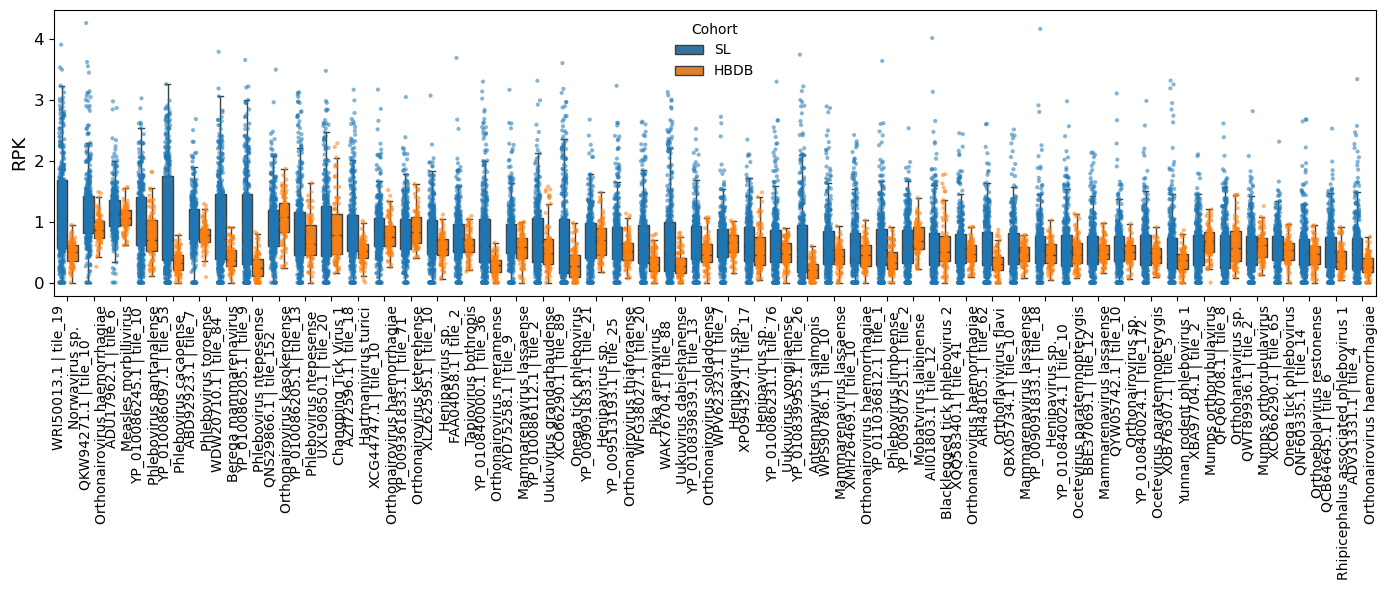

In [248]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=plot_data,
    x='peptide_species_label',
    y='log10_RPK',
    hue='cohort',
    showfliers=False,
    ax=ax
)

sns.stripplot(
    data=plot_data,
    x='peptide_species_label',
    y='log10_RPK',
    hue='cohort',
    dodge=True,
    jitter=0.2,
    alpha=0.55,
    size=3,
    ax=ax
)

ax.set_xlabel('')
ax.set_ylabel('RPK', fontsize=13)

ax.tick_params(
    axis='x',
    labelsize=10,
    rotation=90
)

ax.tick_params(
    axis='y',
    labelsize=12
)

# Remove duplicated legend
handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[:2],
    labels[:2],
    title='Cohort',
    frameon=False
)

plt.tight_layout()
plt.show()

### calculate genus breadth 